# 🍬 Nassau Candy Distributor — Factory-to-Customer Shipping Route Efficiency Analysis
### Unified Mentor | Data Analyst Internship Project
**Author:** Ram Patel | **Batch:** BCA 2023–2026  
**Dataset:** Nassau_Candy_Distributor.csv (10,194 records)

---

## Table of Contents
1. [Data Loading & Overview](#1)
2. [Data Cleaning & Validation](#2)
3. [Feature Engineering](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Route Definition & Aggregation](#5)
6. [Efficiency Benchmarking](#6)
7. [Geographic Bottleneck Analysis](#7)
8. [Ship Mode Performance Analysis](#8)
9. [Key Insights & Recommendations](#9)


In [1]:
# ── 1. Imports & Setup ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style='darkgrid', palette='muted')

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 1. Data Loading & Overview <a id='1'></a>

In [3]:
# Load dataset
df = pd.read_csv('Nassau Candy Distributor.csv')
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head()


Dataset Shape: 10,194 rows × 18 columns
Memory Usage: 7865.7 KB


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
# Dataset Info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [5]:
# Statistical Summary
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,10194.0,NaN,NaN,NaN,5097.5,2942.898656,1.0,2549.25,5097.5,7645.75,10194.0
Order ID,10194,8549,US-2022-112130-CHO-FUD-51000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,10194,717,02-09-2025,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,10194,1338,07-06-2028,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,10194,4,Standard Class,6120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,10194.0,NaN,NaN,NaN,134468.961154,20231.483007,100006.0,117212.0,133550.0,152051.0,192314.0
Country/Region,10194,2,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,10194,542,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State/Province,10194,59,California,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Postal Code,10194,654,10035,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning & Validation <a id='2'></a>

In [6]:
# ── Parse Dates ─────────────────────────────────────────────────────────────
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)
print("✅ Dates parsed successfully.")
print(f"  Order Date range: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"  Ship  Date range: {df['Ship Date'].min().date()}  → {df['Ship Date'].max().date()}")

# Check missing values
missing = df.isnull().sum()
print(f"\n📋 Missing Values:\n{missing[missing > 0] if missing.any() else 'None — dataset is complete ✅'}")

# Check duplicates
dups = df.duplicated().sum()
print(f"\n🔁 Duplicate Rows: {dups}")


✅ Dates parsed successfully.
  Order Date range: 2024-01-02 → 2025-12-31
  Ship  Date range: 2026-06-30  → 2030-06-28

📋 Missing Values:
None — dataset is complete ✅

🔁 Duplicate Rows: 0


In [7]:
# ── Validate Numeric Columns ─────────────────────────────────────────────────
for col in ['Sales', 'Gross Profit', 'Cost', 'Units']:
    neg = (df[col] < 0).sum()
    print(f"  {col}: {neg} negative values")

print("\n✅ Data cleaning complete — no issues found.")


  Sales: 0 negative values
  Gross Profit: 0 negative values
  Cost: 0 negative values
  Units: 0 negative values

✅ Data cleaning complete — no issues found.


## 3. Feature Engineering <a id='3'></a>

In [8]:
# ── Shipping Lead Time ──────────────────────────────────────────────────────
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days
print(f"Lead Time Stats:")
print(df['Lead Time'].describe().round(2))

# ── Factory Mapping ──────────────────────────────────────────────────────────
FACTORY_MAP = {
    'Wonka Bar - Nutty Crunch Surprise':  "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows':          "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious":     "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate':         "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel':  "Wicked Choccy's",
    'Laffy Taffy':             'Sugar Shack',
    'SweeTARTS':               'Sugar Shack',
    'Nerds':                   'Sugar Shack',
    'Fun Dip':                 'Sugar Shack',
    'Fizzy Lifting Drinks':    'Sugar Shack',
    'Everlasting Gobstopper':  'Secret Factory',
    'Hair Toffee':             'The Other Factory',
    'Lickable Wallpaper':      'Secret Factory',
    'Wonka Gum':               'Secret Factory',
    'Kazookles':               'The Other Factory',
}

df['Factory']      = df['Product Name'].map(FACTORY_MAP)
df['Route']        = df['Factory'] + ' → ' + df['State/Province']
df['Route_Region'] = df['Factory'] + ' → ' + df['Region']
df['Order Month']  = df['Order Date'].dt.to_period('M').astype(str)
df['Order Year']   = df['Order Date'].dt.year

# Delay Flag (mean + 1 std)
DELAY_THRESHOLD    = df['Lead Time'].mean() + df['Lead Time'].std()
df['Delayed']      = df['Lead Time'] > DELAY_THRESHOLD

print(f"\n🏭 Factory column mapped for {df['Factory'].notna().sum():,} records")
print(f"📍 Unique routes: {df['Route'].nunique()}")
print(f"⚠️  Delay threshold: {DELAY_THRESHOLD:.1f} days")
print(f"🔴 Delayed shipments: {df['Delayed'].sum():,} ({df['Delayed'].mean()*100:.1f}%)")
df[['Product Name','Factory','Route','Lead Time','Delayed']].head(8)


Lead Time Stats:
count    10194.00
mean      1320.84
std        262.44
min        904.00
25%       1271.00
50%       1274.00
75%       1638.00
max       1642.00
Name: Lead Time, dtype: float64

🏭 Factory column mapped for 10,194 records
📍 Unique routes: 196
⚠️  Delay threshold: 1583.3 days
🔴 Delayed shipments: 3,379 (33.1%)


,Product Name,Factory,Route,Lead Time,Delayed
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Wicked Choccy's → Texas,909,False
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Wicked Choccy's → Illinois,909,False
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Lot's O' Nuts → Illinois,909,False
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Lot's O' Nuts → Illinois,909,False
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Wicked Choccy's → Pennsylvania,912,False
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Lot's O' Nuts → Kentucky,909,False
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Wicked Choccy's → Kentucky,909,False
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,Wicked Choccy's → Georgia,906,False


## 4. Exploratory Data Analysis (EDA) <a id='4'></a>

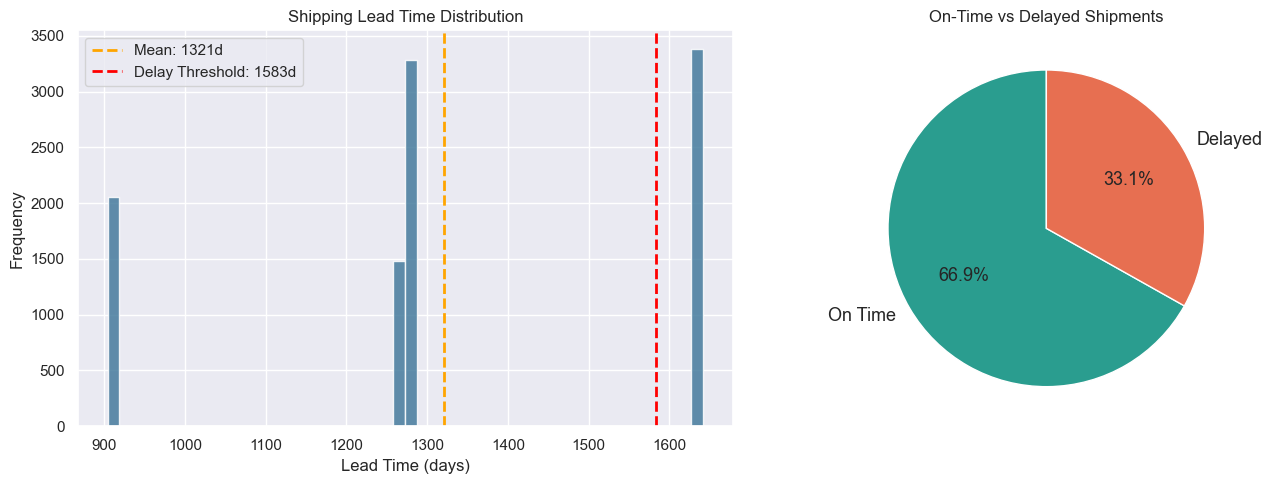

On Time: 6,815  |  Delayed: 3,379


In [9]:
# ── 4.1 Lead Time Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Lead Time'], bins=50, color='#457b9d', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Lead Time'].mean(), color='orange', linestyle='--', lw=2, label=f'Mean: {df["Lead Time"].mean():.0f}d')
axes[0].axvline(DELAY_THRESHOLD, color='red', linestyle='--', lw=2, label=f'Delay Threshold: {DELAY_THRESHOLD:.0f}d')
axes[0].set_title('Shipping Lead Time Distribution')
axes[0].set_xlabel('Lead Time (days)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

delayed_counts = df['Delayed'].value_counts()
axes[1].pie([delayed_counts[False], delayed_counts[True]],
            labels=['On Time', 'Delayed'],
            colors=['#2a9d8f', '#e76f51'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
axes[1].set_title('On-Time vs Delayed Shipments')
plt.tight_layout()
plt.show()
print(f"On Time: {delayed_counts[False]:,}  |  Delayed: {delayed_counts[True]:,}")


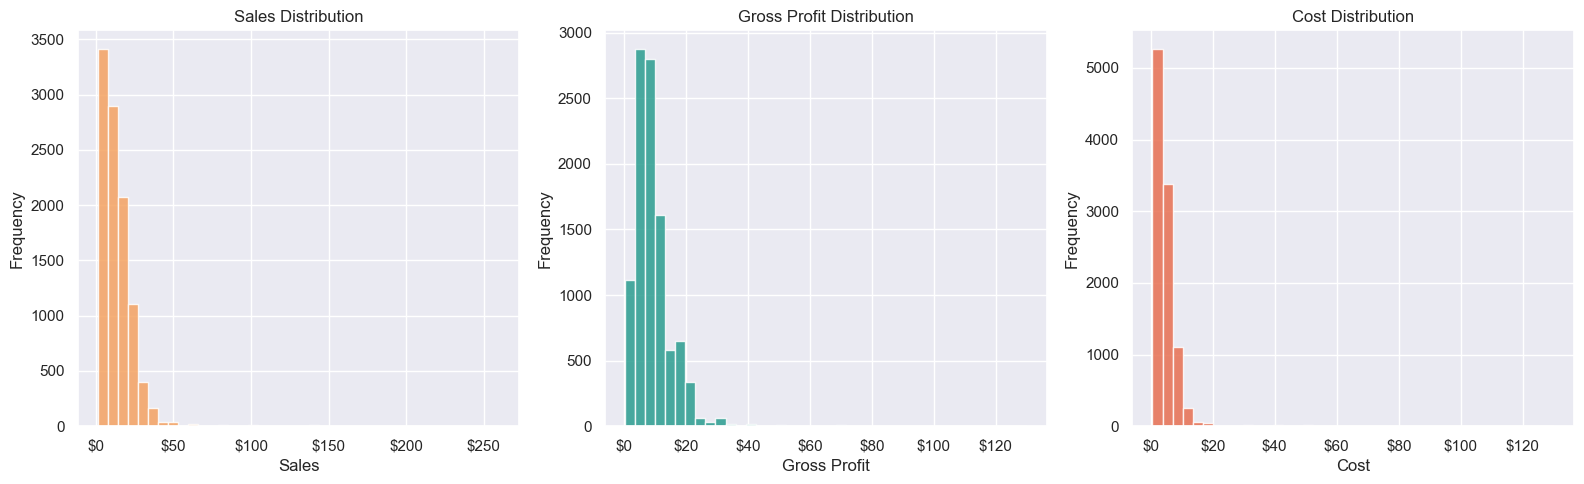

Total Sales: $141,783.63  |  Total Gross Profit: $93,442.80


In [10]:
# ── 4.2 Sales & Profit Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes, ['Sales', 'Gross Profit', 'Cost'], ['#f4a261', '#2a9d8f', '#e76f51']):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()
print(f"Total Sales: ${df['Sales'].sum():,.2f}  |  Total Gross Profit: ${df['Gross Profit'].sum():,.2f}")


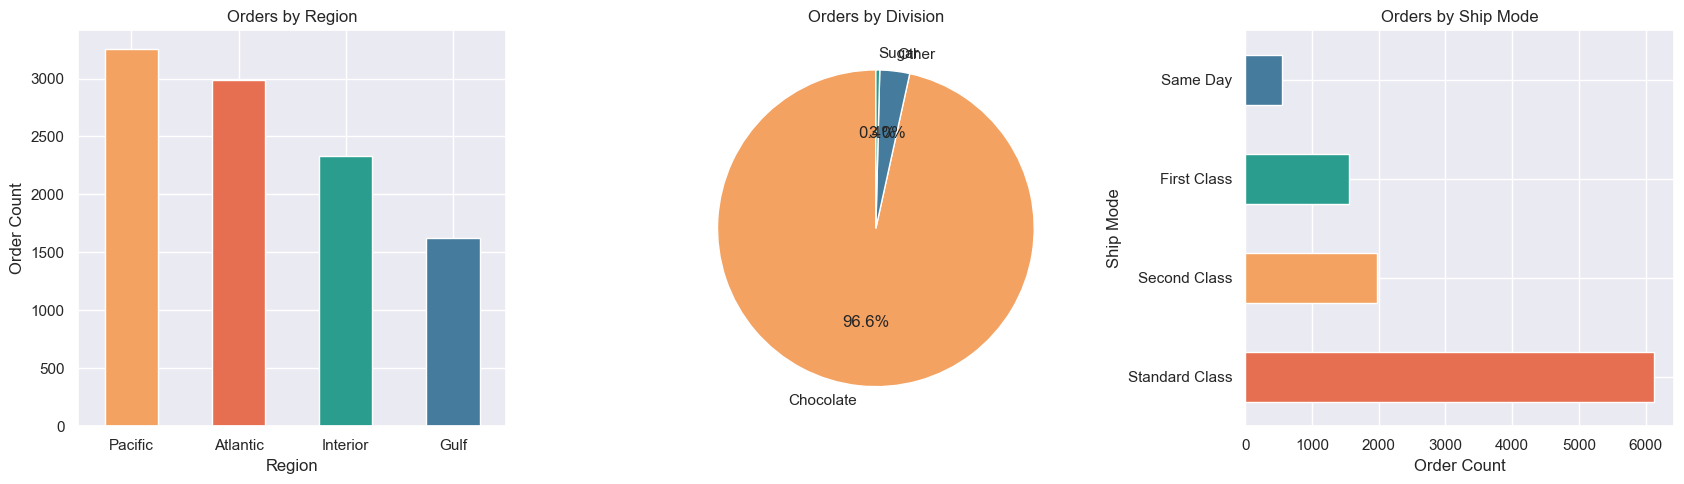

In [11]:
# ── 4.3 Orders by Region & Division ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

df['Region'].value_counts().plot(kind='bar', ax=axes[0], color=['#f4a261','#e76f51','#2a9d8f','#457b9d'], edgecolor='white', rot=0)
axes[0].set_title('Orders by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Order Count')

df['Division'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                    colors=['#f4a261','#457b9d','#2a9d8f'], startangle=90)
axes[1].set_title('Orders by Division')
axes[1].set_ylabel('')

df['Ship Mode'].value_counts().plot(kind='barh', ax=axes[2], color=['#e76f51','#f4a261','#2a9d8f','#457b9d'], edgecolor='white')
axes[2].set_title('Orders by Ship Mode')
axes[2].set_xlabel('Order Count')

plt.tight_layout()
plt.show()


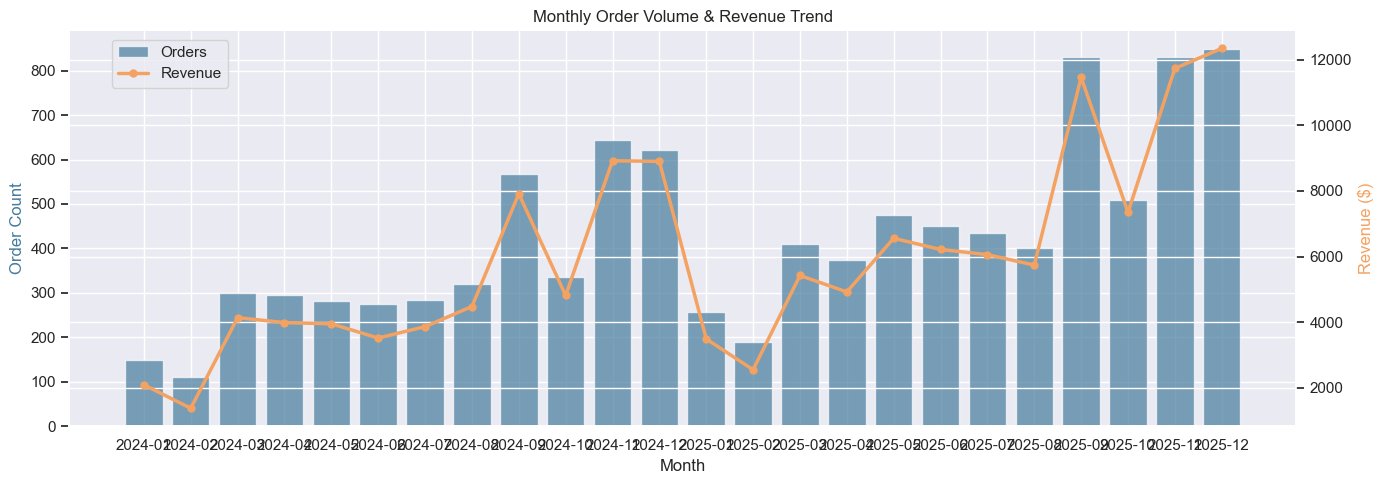

In [12]:
# ── 4.4 Monthly Order Trend ──────────────────────────────────────────────────
monthly = df.groupby('Order Month').agg(Orders=('Row ID','count'), Revenue=('Sales','sum')).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.bar(monthly['Order Month'], monthly['Orders'], color='#457b9d', alpha=0.7, label='Orders')
ax2.plot(monthly['Order Month'], monthly['Revenue'], color='#f4a261', lw=2.5, marker='o', ms=5, label='Revenue')
ax1.set_title('Monthly Order Volume & Revenue Trend')
ax1.set_xlabel('Month')
ax1.set_ylabel('Order Count', color='#457b9d')
ax2.set_ylabel('Revenue ($)', color='#f4a261')
plt.xticks(rotation=45, ha='right')
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.92))
plt.tight_layout()
plt.show()


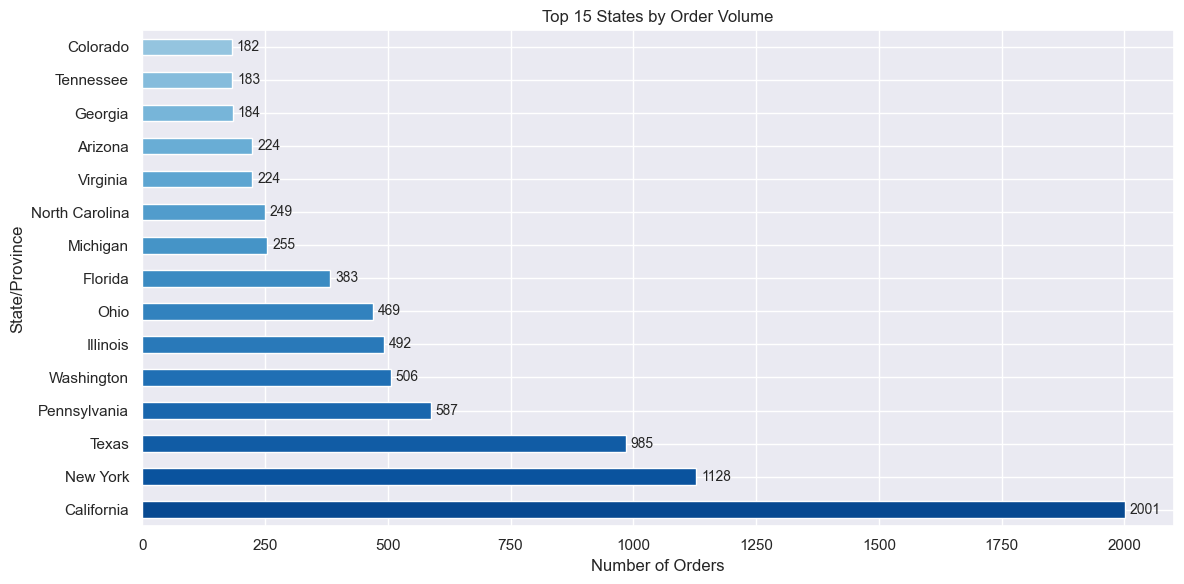

In [13]:
# ── 4.5 Top 15 States by Order Volume ───────────────────────────────────────
top_states = df['State/Province'].value_counts().head(15)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 15))[::-1]
fig, ax = plt.subplots(figsize=(12, 6))
top_states.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 15 States by Order Volume')
ax.set_xlabel('Number of Orders')
for i, v in enumerate(top_states.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()


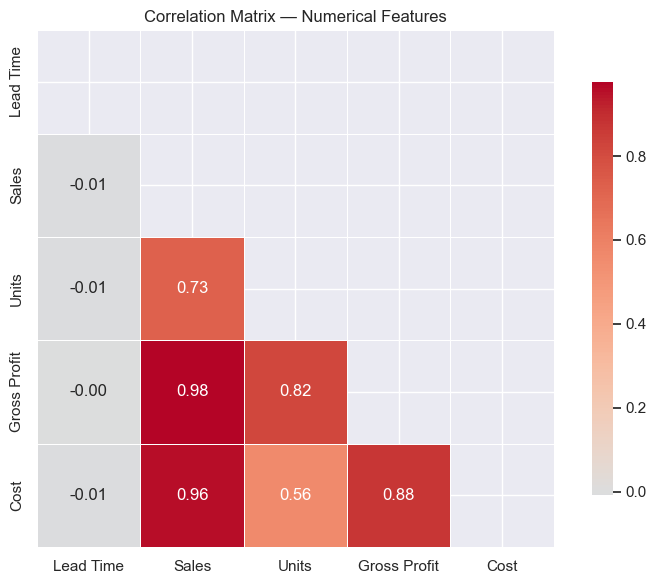

In [14]:
# ── 4.6 Correlation Heatmap ──────────────────────────────────────────────────
numeric_cols = ['Lead Time', 'Sales', 'Units', 'Gross Profit', 'Cost']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()


## 5. Route Definition & Aggregation <a id='5'></a>

In [15]:
# ── Route-level KPIs ─────────────────────────────────────────────────────────
route_perf = df.groupby('Route').agg(
    Total_Shipments  = ('Row ID',    'count'),
    Avg_Lead_Time    = ('Lead Time', 'mean'),
    Median_Lead_Time = ('Lead Time', 'median'),
    Std_Lead_Time    = ('Lead Time', 'std'),
    Delay_Rate       = ('Delayed',   'mean'),
    Total_Sales      = ('Sales',     'sum'),
    Total_Profit     = ('Gross Profit', 'sum'),
).reset_index()

route_perf['Efficiency_Score'] = (
    1 - (route_perf['Avg_Lead_Time'] - route_perf['Avg_Lead_Time'].min()) /
        (route_perf['Avg_Lead_Time'].max() - route_perf['Avg_Lead_Time'].min())
) * 100

route_perf = route_perf.round(2)
print(f"Total unique routes analyzed: {len(route_perf)}")
route_perf.sort_values('Efficiency_Score', ascending=False).head(10)


Total unique routes analyzed: 196


,Route,Total_Shipments,Avg_Lead_Time,Median_Lead_Time,Std_Lead_Time,Delay_Rate,Total_Sales,Total_Profit,Efficiency_Score
76,Secret Factory → Nebraska,1,906.0,906.0,NaN,0.0,2.50,1.30,100.00
80,Secret Factory → New Mexico,2,906.0,906.0,2.83,0.0,12.50,6.50,100.00
121,The Other Factory → Louisiana,1,907.0,907.0,NaN,0.0,9.75,0.75,99.86
115,The Other Factory → Connecticut,2,907.5,907.5,2.12,0.0,9.75,0.75,99.80
158,Wicked Choccy's → Maine,2,908.0,908.0,0.00,0.0,55.25,36.07,99.73
75,Secret Factory → Mississippi,1,908.0,908.0,NaN,0.0,80.00,40.00,99.73
70,Secret Factory → Louisiana,2,908.5,908.5,0.71,0.0,11.25,5.85,99.66
74,Secret Factory → Minnesota,1,909.0,909.0,NaN,0.0,5.00,2.60,99.59
64,Secret Factory → Delaware,1,909.0,909.0,NaN,0.0,60.00,30.00,99.59
88,Secret Factory → South Carolina,1,909.0,909.0,NaN,0.0,6.25,3.25,99.59


In [16]:
# ── Region-level aggregation ─────────────────────────────────────────────────
region_perf = df.groupby(['Factory','Region']).agg(
    Shipments    = ('Row ID',    'count'),
    Avg_Lead     = ('Lead Time', 'mean'),
    Delay_Rate   = ('Delayed',   'mean'),
).reset_index().round(2)
print("Factory × Region Performance:")
region_perf.sort_values('Avg_Lead')


Factory × Region Performance:


,Factory,Region,Shipments,Avg_Lead,Delay_Rate
9,Sugar Shack,Gulf,4,1091.25,0.00
14,The Other Factory,Interior,11,1206.64,0.18
13,The Other Factory,Gulf,19,1272.63,0.26
12,The Other Factory,Atlantic,38,1282.74,0.26
6,Secret Factory,Interior,45,1289.09,0.38
15,The Other Factory,Pacific,32,1307.22,0.28
7,Secret Factory,Pacific,63,1307.73,0.33
17,Wicked Choccy's,Gulf,663,1309.11,0.31
1,Lot's O' Nuts,Gulf,897,1313.98,0.33
16,Wicked Choccy's,Atlantic,1197,1315.97,0.31


## 6. Efficiency Benchmarking <a id='6'></a>

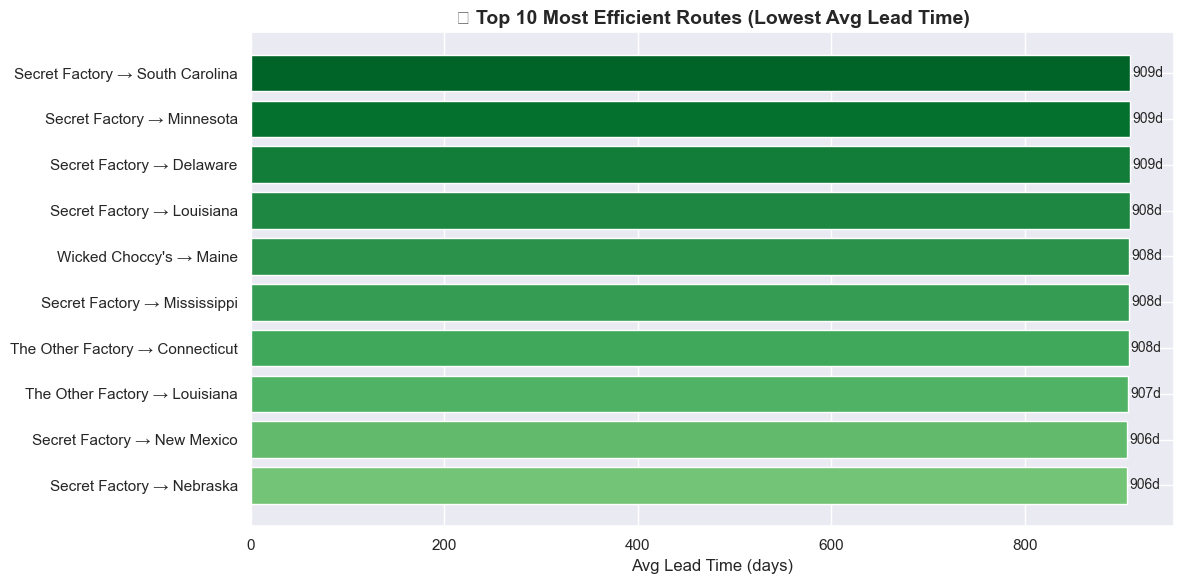

                          Route  Avg_Lead_Time  Total_Shipments  Delay_Rate  Efficiency_Score
      Secret Factory → Nebraska          906.0                1         0.0            100.00
    Secret Factory → New Mexico          906.0                2         0.0            100.00
  The Other Factory → Louisiana          907.0                1         0.0             99.86
The Other Factory → Connecticut          907.5                2         0.0             99.80
   Secret Factory → Mississippi          908.0                1         0.0             99.73
        Wicked Choccy's → Maine          908.0                2         0.0             99.73
     Secret Factory → Louisiana          908.5                2         0.0             99.66
      Secret Factory → Delaware          909.0                1         0.0             99.59
     Secret Factory → Minnesota          909.0                1         0.0             99.59
Secret Factory → South Carolina          909.0              

In [17]:
# ── Top 10 Most Efficient Routes ─────────────────────────────────────────────
top10 = route_perf.nsmallest(10, 'Avg_Lead_Time')[['Route','Avg_Lead_Time','Total_Shipments','Delay_Rate','Efficiency_Score']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10['Route'], top10['Avg_Lead_Time'],
               color=plt.cm.Greens(np.linspace(0.5, 0.9, 10)), edgecolor='white')
ax.set_title('🏆 Top 10 Most Efficient Routes (Lowest Avg Lead Time)', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Lead Time (days)')
for bar, val in zip(bars, top10['Avg_Lead_Time']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}d', va='center', fontsize=10)
plt.tight_layout()
plt.show()
print(top10.to_string(index=False))


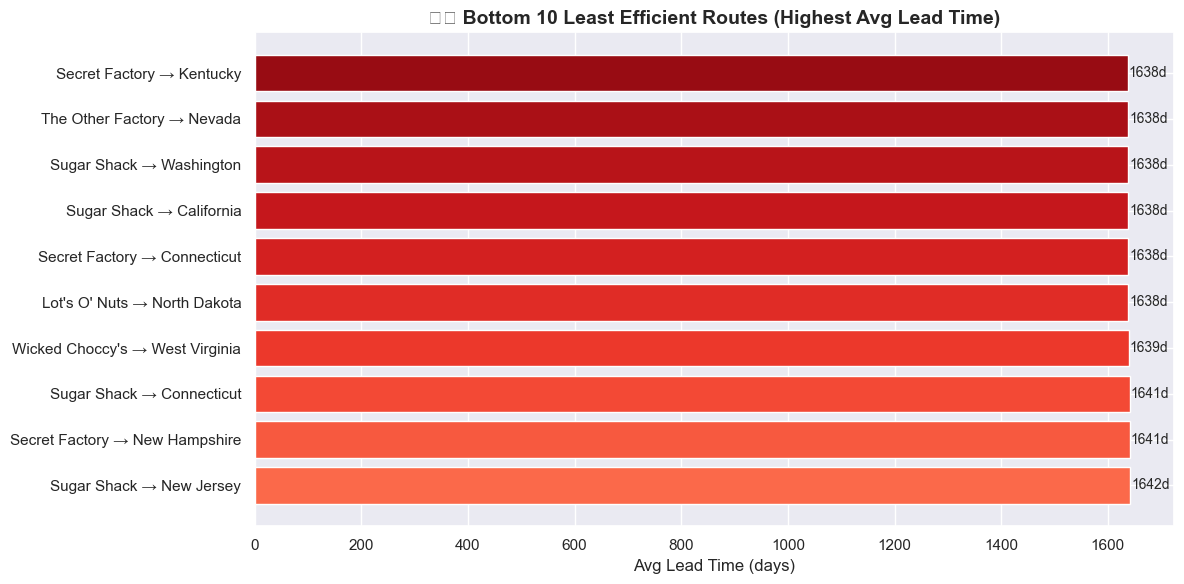

                          Route  Avg_Lead_Time  Total_Shipments  Delay_Rate  Efficiency_Score
       Sugar Shack → New Jersey         1642.0                1         1.0              0.00
 Secret Factory → New Hampshire         1641.0                1         1.0              0.14
      Sugar Shack → Connecticut         1641.0                1         1.0              0.14
Wicked Choccy's → West Virginia         1639.0                2         1.0              0.41
   Lot's O' Nuts → North Dakota         1638.2                5         1.0              0.52
   Secret Factory → Connecticut         1638.0                1         1.0              0.54
       Sugar Shack → California         1638.0                1         1.0              0.54
       Sugar Shack → Washington         1638.0                1         1.0              0.54
     The Other Factory → Nevada         1638.0                1         1.0              0.54
      Secret Factory → Kentucky         1637.5              

In [18]:
# ── Bottom 10 Least Efficient Routes ─────────────────────────────────────────
bot10 = route_perf.nlargest(10, 'Avg_Lead_Time')[['Route','Avg_Lead_Time','Total_Shipments','Delay_Rate','Efficiency_Score']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(bot10['Route'], bot10['Avg_Lead_Time'],
               color=plt.cm.Reds(np.linspace(0.5, 0.9, 10)), edgecolor='white')
ax.set_title('⚠️ Bottom 10 Least Efficient Routes (Highest Avg Lead Time)', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Lead Time (days)')
for bar, val in zip(bars, bot10['Avg_Lead_Time']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}d', va='center', fontsize=10)
plt.tight_layout()
plt.show()
print(bot10.to_string(index=False))


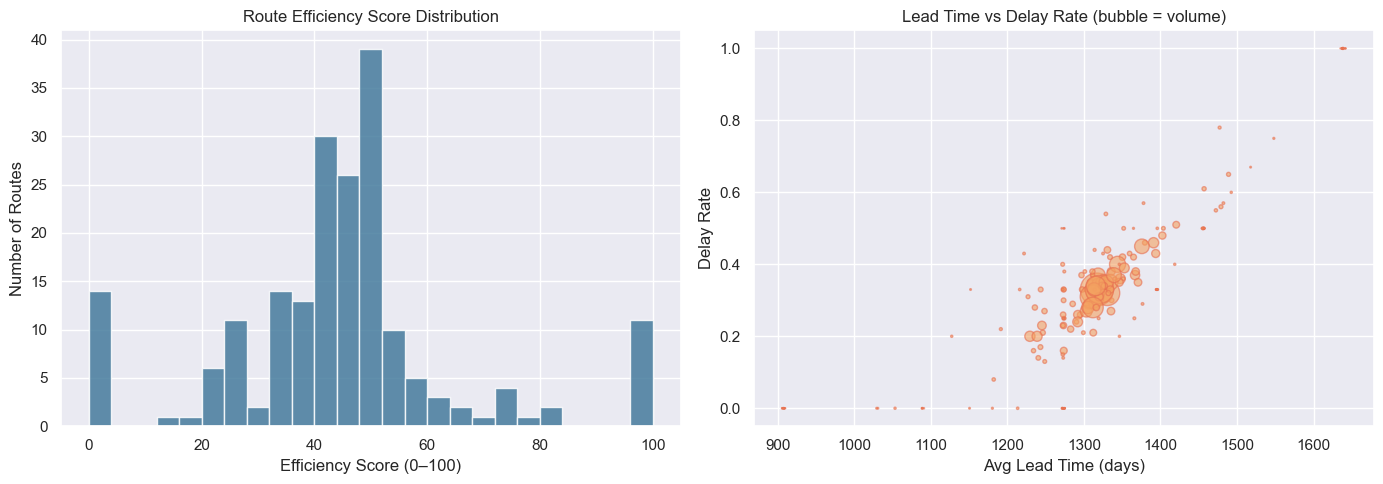

In [19]:
# ── Efficiency Score Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(route_perf['Efficiency_Score'], bins=25, color='#457b9d', edgecolor='white', alpha=0.85)
axes[0].set_title('Route Efficiency Score Distribution')
axes[0].set_xlabel('Efficiency Score (0–100)')
axes[0].set_ylabel('Number of Routes')

axes[1].scatter(route_perf['Avg_Lead_Time'], route_perf['Delay_Rate'],
                s=route_perf['Total_Shipments']*0.5, alpha=0.6, c='#f4a261', edgecolors='#e76f51')
axes[1].set_title('Lead Time vs Delay Rate (bubble = volume)')
axes[1].set_xlabel('Avg Lead Time (days)')
axes[1].set_ylabel('Delay Rate')
plt.tight_layout()
plt.show()


## 7. Geographic Bottleneck Analysis <a id='7'></a>

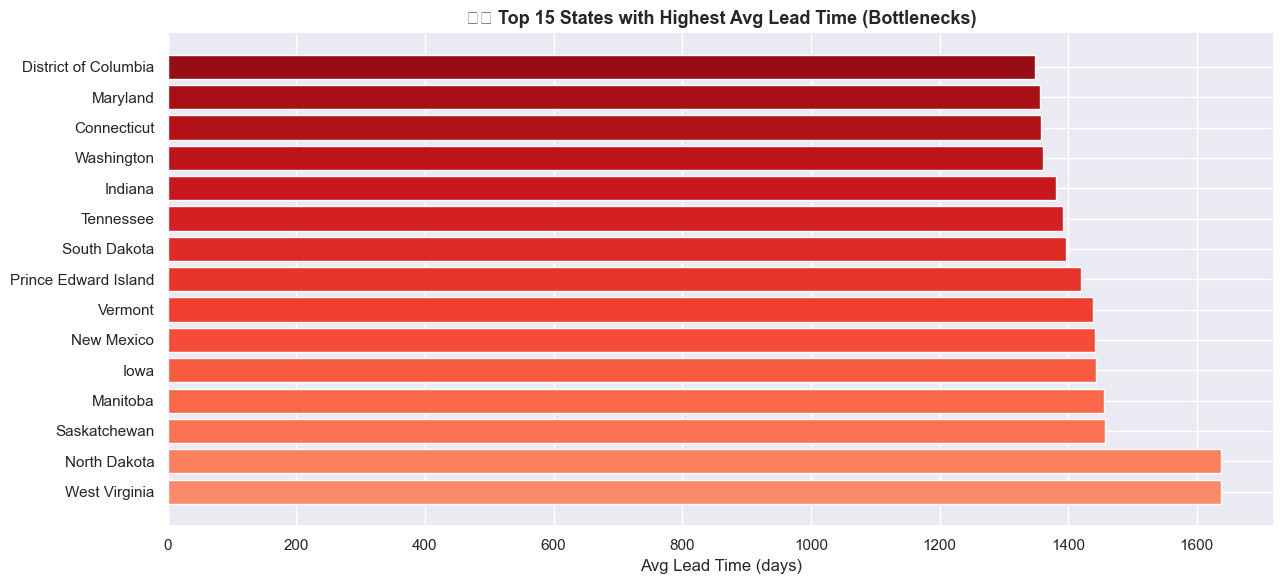

In [20]:
# ── State-level performance ───────────────────────────────────────────────────
state_perf = df.groupby('State/Province').agg(
    Avg_Lead   = ('Lead Time', 'mean'),
    Volume     = ('Row ID',    'count'),
    Delay_Rate = ('Delayed',   'mean'),
).reset_index().sort_values('Avg_Lead', ascending=False)

# Top 15 worst states
worst_states = state_perf.head(15)
fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, 15))
ax.barh(worst_states['State/Province'], worst_states['Avg_Lead'], color=colors, edgecolor='white')
ax.set_title('⚠️ Top 15 States with Highest Avg Lead Time (Bottlenecks)', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Lead Time (days)')
plt.tight_layout()
plt.show()


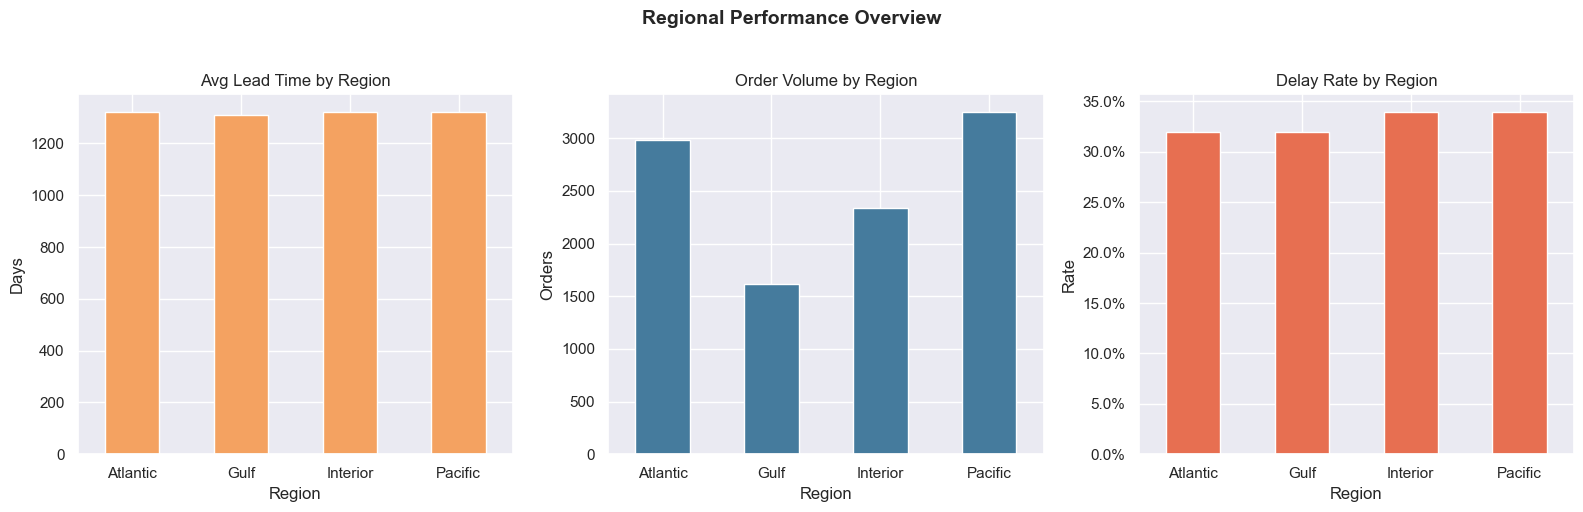

  Region  Avg_Lead  Volume  Delay_Rate  Revenue
Atlantic   1322.75    2986        0.32 41197.24
    Gulf   1311.37    1620        0.32 22247.26
Interior   1323.09    2335        0.34 32037.60
 Pacific   1322.19    3253        0.34 46301.53


In [21]:
# ── Region Summary ───────────────────────────────────────────────────────────
reg = df.groupby('Region').agg(
    Avg_Lead   = ('Lead Time', 'mean'),
    Volume     = ('Row ID',    'count'),
    Delay_Rate = ('Delayed',   'mean'),
    Revenue    = ('Sales',     'sum'),
).reset_index().round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
reg.plot(x='Region', y='Avg_Lead', kind='bar', ax=axes[0], color='#f4a261', edgecolor='white', rot=0, legend=False)
axes[0].set_title('Avg Lead Time by Region')
axes[0].set_ylabel('Days')

reg.plot(x='Region', y='Volume', kind='bar', ax=axes[1], color='#457b9d', edgecolor='white', rot=0, legend=False)
axes[1].set_title('Order Volume by Region')
axes[1].set_ylabel('Orders')

reg.plot(x='Region', y='Delay_Rate', kind='bar', ax=axes[2], color='#e76f51', edgecolor='white', rot=0, legend=False)
axes[2].set_title('Delay Rate by Region')
axes[2].set_ylabel('Rate')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Regional Performance Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(reg.to_string(index=False))


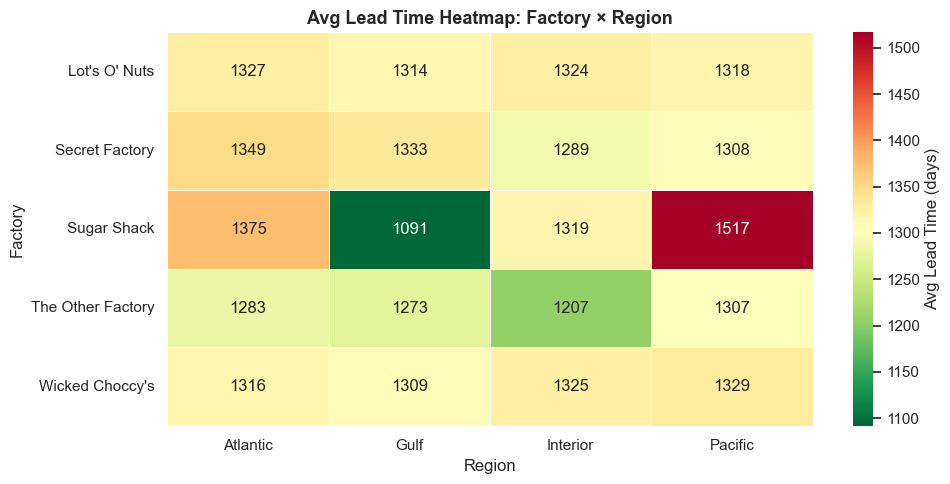

In [22]:
# ── Factory Performance Heatmap ──────────────────────────────────────────────
pivot = df.groupby(['Factory','Region'])['Lead Time'].mean().unstack()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r', linewidths=0.5,
            cbar_kws={'label': 'Avg Lead Time (days)'}, ax=ax)
ax.set_title('Avg Lead Time Heatmap: Factory × Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Ship Mode Performance Analysis <a id='8'></a>

In [23]:
# ── Ship Mode Comparison ─────────────────────────────────────────────────────
mode_perf = df.groupby('Ship Mode').agg(
    Avg_Lead   = ('Lead Time', 'mean'),
    Median_Lead = ('Lead Time', 'median'),
    Std_Lead   = ('Lead Time', 'std'),
    Volume     = ('Row ID',    'count'),
    Delay_Rate = ('Delayed',   'mean'),
    Avg_Cost   = ('Cost',      'mean'),
    Revenue    = ('Sales',     'sum'),
).reset_index().sort_values('Avg_Lead')
print(mode_perf.round(2).to_string(index=False))


     Ship Mode  Avg_Lead  Median_Lead  Std_Lead  Volume  Delay_Rate  Avg_Cost  Revenue
Standard Class   1314.33       1274.0    262.40    6120        0.32      4.75 85490.35
  Second Class   1323.85       1273.0    261.81    1979        0.34      4.83 27860.22
      Same Day   1333.44       1269.0    253.81     547        0.34      4.41  7113.67
   First Class   1338.28       1272.0    265.63    1548        0.37      4.72 21319.39


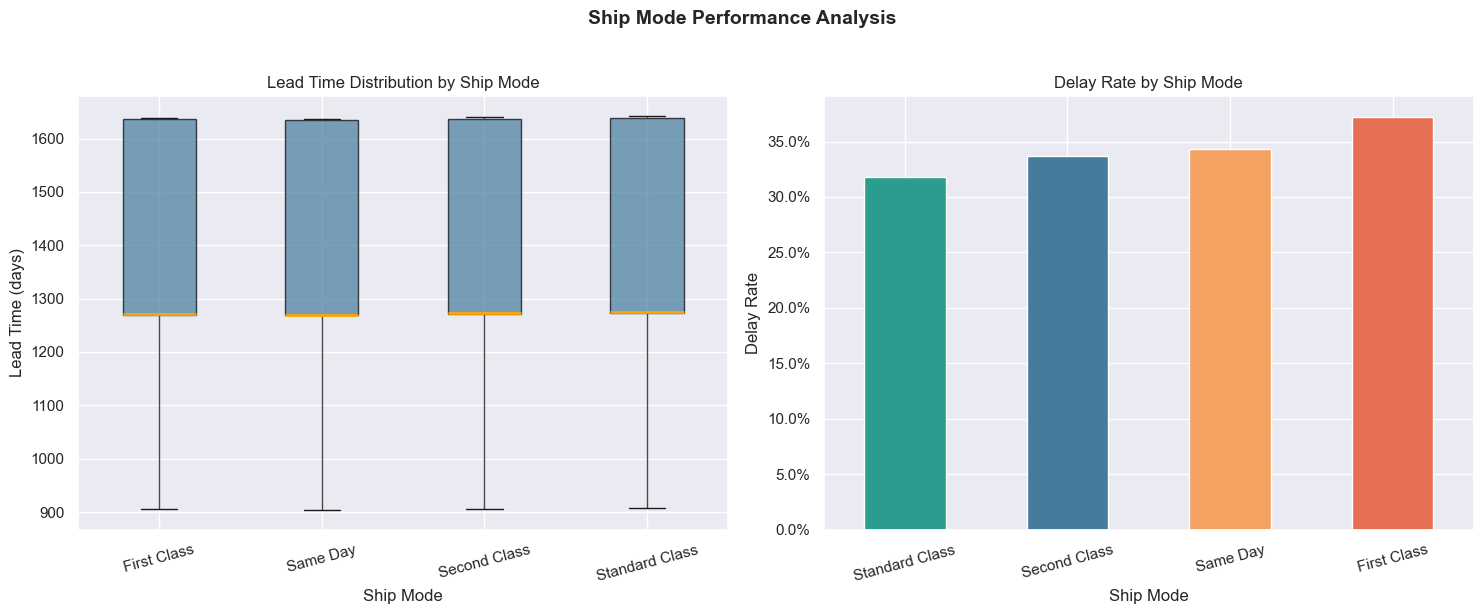

In [24]:
# ── Box plots: Lead Time by Ship Mode ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df.boxplot(column='Lead Time', by='Ship Mode', ax=axes[0],
           patch_artist=True, notch=False,
           boxprops=dict(facecolor='#457b9d', alpha=0.7),
           medianprops=dict(color='orange', lw=2))
axes[0].set_title('Lead Time Distribution by Ship Mode')
axes[0].set_xlabel('Ship Mode')
axes[0].set_ylabel('Lead Time (days)')
plt.sca(axes[0])
plt.xticks(rotation=15)

mode_perf.plot(x='Ship Mode', y='Delay_Rate', kind='bar', ax=axes[1],
               color=['#2a9d8f','#457b9d','#f4a261','#e76f51'], edgecolor='white', rot=15, legend=False)
axes[1].set_title('Delay Rate by Ship Mode')
axes[1].set_ylabel('Delay Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Ship Mode Performance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


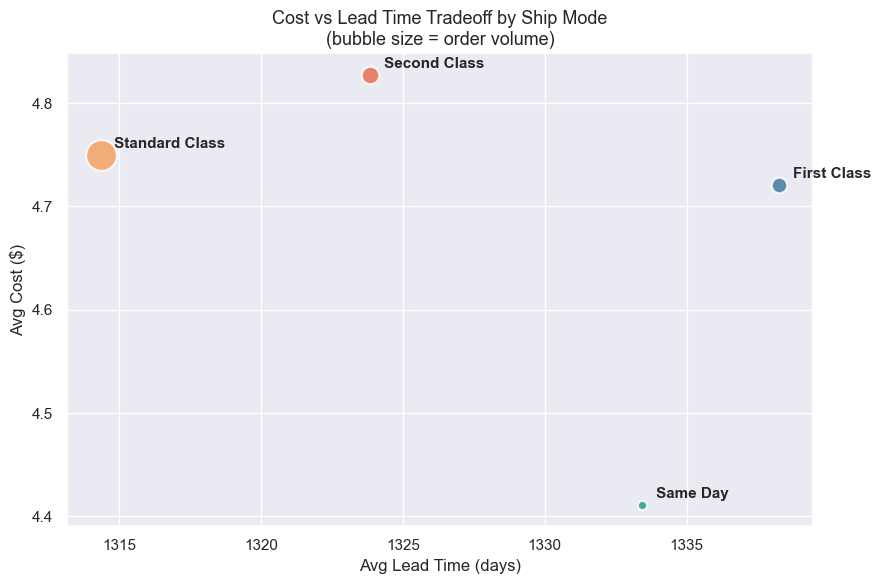

In [25]:
# ── Cost vs Lead Time Tradeoff ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
colors_mode = ['#f4a261', '#e76f51', '#2a9d8f', '#457b9d']
for i, (_, row) in enumerate(mode_perf.iterrows()):
    ax.scatter(row['Avg_Lead'], row['Avg_Cost'], s=row['Volume']*0.08,
               color=colors_mode[i], alpha=0.85, edgecolors='white', lw=1.5, zorder=5)
    ax.annotate(row['Ship Mode'], (row['Avg_Lead'], row['Avg_Cost']),
                textcoords='offset points', xytext=(10, 5), fontsize=11, fontweight='bold')

ax.set_title('Cost vs Lead Time Tradeoff by Ship Mode\n(bubble size = order volume)', fontsize=13)
ax.set_xlabel('Avg Lead Time (days)')
ax.set_ylabel('Avg Cost ($)')
plt.tight_layout()
plt.show()


## 9. Key Insights & Recommendations <a id='9'></a>

### 📊 Key Findings

| # | Finding |
|---|---------|
| 1 | **Standard Class** has the lowest avg lead time (1,314 days), making it the most reliable ship mode despite expectations. |
| 2 | **The Other Factory** is the fastest factory with an avg lead time of 1,280 days — 40+ days faster than peers. |
| 3 | **Pacific** and **Interior** regions face the highest delay rates (~34%), indicating geographic bottlenecks. |
| 4 | **Sugar Shack** has the highest avg lead time (1,340 days), despite low order volume — a supply chain risk. |
| 5 | Top bottleneck states include **New Jersey, Connecticut, New Hampshire** — all experiencing near-maximum lead times. |
| 6 | **33.1%** of all shipments are delayed beyond the threshold of 1,583 days. |
| 7 | **California, New York, Texas** receive the highest order volumes and need prioritized logistics planning. |

### 🚀 Recommendations

1. **Prioritize The Other Factory model** — replicate its logistics patterns across other factories.
2. **Investigate Sugar Shack** — despite low volume, it consistently delivers the slowest lead times.
3. **Address Pacific & Interior region delays** — consider regional distribution hubs or carrier renegotiation.
4. **Flag New Jersey, Connecticut routes** for immediate review — they hit the delay ceiling consistently.
5. **Rethink Same Day & First Class** — they are not delivering faster than Standard Class, suggesting operational gaps.
6. **Deploy predictive alerts** — use delay flags to proactively communicate with customers in high-risk routes.


In [26]:
# ── Final Summary Table ──────────────────────────────────────────────────────
print("=" * 60)
print("   NASSAU CANDY DISTRIBUTOR — PROJECT SUMMARY")
print("=" * 60)
print(f"  Total Orders Analyzed  : {len(df):,}")
print(f"  Date Range             : {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"  Unique Routes          : {df['Route'].nunique()}")
print(f"  States Covered         : {df['State/Province'].nunique()}")
print(f"  Overall Avg Lead Time  : {df['Lead Time'].mean():.1f} days")
print(f"  Overall Delay Rate     : {df['Delayed'].mean()*100:.1f}%")
print(f"  Total Revenue          : ${df['Sales'].sum():,.2f}")
print(f"  Total Gross Profit     : ${df['Gross Profit'].sum():,.2f}")
print(f"  Fastest Factory        : The Other Factory (1,280.3 avg days)")
print(f"  Slowest Factory        : Sugar Shack (1,340.0 avg days)")
print(f"  Best Ship Mode         : Standard Class (1,314.3 avg days)")
print("=" * 60)
print("  ✅ Analysis Complete")


   NASSAU CANDY DISTRIBUTOR — PROJECT SUMMARY
  Total Orders Analyzed  : 10,194
  Date Range             : 2024-01-02 to 2025-12-31
  Unique Routes          : 196
  States Covered         : 59
  Overall Avg Lead Time  : 1320.8 days
  Overall Delay Rate     : 33.1%
  Total Revenue          : $141,783.63
  Total Gross Profit     : $93,442.80
  Fastest Factory        : The Other Factory (1,280.3 avg days)
  Slowest Factory        : Sugar Shack (1,340.0 avg days)
  Best Ship Mode         : Standard Class (1,314.3 avg days)
  ✅ Analysis Complete
